In [1]:
import sys
import os
base_dir = os.path.dirname(__file__) if '__file__' in globals() else os.getcwd()
sys.path.append(os.path.abspath(os.path.join(base_dir, '..')))
import argparse
from tqdm import tqdm
from torch import optim
from MvDST_gpu_beta import MvDST
from utils import *
import torch.nn.functional as F
import pandas as pd
from utils import get_logger
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
import os
import scipy.sparse as sparse
import anndata
import seaborn as sns
import time
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3
sns.set_style("white")
np.random.seed(0)
import math
import pandas as pd
import tifffile
import scanpy as sc
import numpy as np
from PIL import Image
from sklearn.metrics import adjusted_rand_score
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=400, frameon=True, vector_friendly=False, fontsize=12, figsize=(8, 4), color_map=None, format='eps', facecolor=None, transparent=True, ipython_format='png2x')


scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.23.5 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [2]:
filepath='../Data/STARmaps/'
### read dapi: col, row, z
dapi = tifffile.imread(filepath+'BY3_dapi.tiff')
# dapi = Image.fromarray(dapi)
spots = pd.read_csv(filepath + 'BY3_raw.csv')
spots.columns = ['gene_name', 'spot_location_1', 'spot_location_2', 'spot_location_3']
genes = pd.DataFrame(spots['gene_name'].unique())
a1 = list(genes[0])
gene = list(map(lambda x: a1.index(x)+1, spots['gene_name']))
spots['gene'] = gene
spots['gene'] = spots['gene'].astype('int')
count_data = pd.read_csv('../Data/STARmaps/generated_count_matrix.csv', index_col=0).values
count_data

array([[1.6792425 , 1.96095222, 4.11396098, ..., 0.        , 0.        ,
        0.        ],
       [0.67667234, 1.76414866, 3.85928388, ..., 0.        , 0.        ,
        0.        ],
       [0.37688177, 2.72061696, 3.99077702, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 2.7293276 , 3.53861905, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.26398555, 2.90376601, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.63141682, 3.24519313, ..., 0.        , 0.        ,
        0.        ]])

In [3]:
spatial_location = pd.read_csv('../Data/STARmaps/spatial.csv', index_col=0).values
adata = anndata.AnnData(X=count_data, var=pd.DataFrame(index=genes))
adata.obsm['spatial'] = spatial_location
adata.obs['tissue_id_refine'] = pd.read_csv('../Data/STARmaps/generated_tissue_id.csv',
                                                index_col=0).values
adata.obs['tissue_id_refine'] = adata.obs['tissue_id_refine'].astype('category')
label = np.array(adata.obs['tissue_id_refine'])

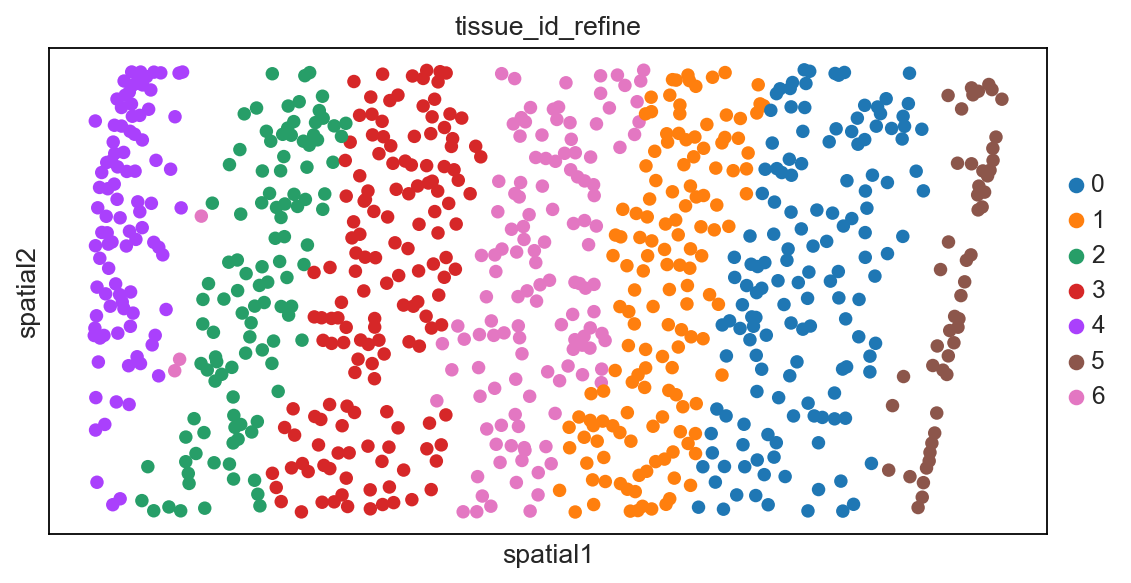

In [4]:
sc.pl.embedding(adata, basis='spatial', color=['tissue_id_refine'])

In [5]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=500)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata, zero_center=False, max_value=10)
enhanced_adata, cell_spatial = mnmst.data_enhance(adata, k_nei=10, ratio=0.4)
feat = np.array(enhanced_adata.X)
adj = cell_spatial.A
adj = np.nan_to_num(cell_spatial.A)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
... be careful when using `max_value` without `zero_center`.

Median distance to closest cell = 342.6670814740716
num_nbrs: 1020


In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_decoder_output, best_predicted_labels, latent_feature = MvDST(
    features=feat,
    true_labels=label,
    adj=adj,
    device=device
)

2025-06-17 17:08:47 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 17:08:47 - root - INFO: - Laplacian smoothing...
2025-06-17 17:08:53 - root - INFO: - --------------------Start Training Loop--------------------
  0%|▎                                                                                                                              | 1/400 [00:01<12:45,  1.92s/it]

<class 'torch.Tensor'>


  3%|███▍                                                                                                                          | 11/400 [00:02<00:51,  7.61it/s]

<class 'torch.Tensor'>


  5%|██████▌                                                                                                                       | 21/400 [00:02<00:23, 15.85it/s]

...

 93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉         | 371/400 [00:09<00:00, 47.89it/s]

<class 'torch.Tensor'>


 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏  | 391/400 [00:10<00:00, 44.94it/s]

<class 'torch.Tensor'>


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:10<00:00, 38.88it/s]
2025-06-17 17:09:03 - root - INFO: - Training Complete. Best ARI: 86.6200, Time: 0m 10s
2025-06-17 17:09:03 - root - INFO: - Peak RAM usage: 3.228 GB
2025-06-17 17:09:03 - root - INFO: - Peak GPU memory usage: 0.106 GB


In [7]:
print(adjusted_rand_score(pd.Categorical(adata.obs['tissue_id_refine']).codes, best_predicted_labels))
ari = adjusted_rand_score(pd.Categorical(adata.obs['tissue_id_refine']).codes, best_predicted_labels)

0.8661657694554119


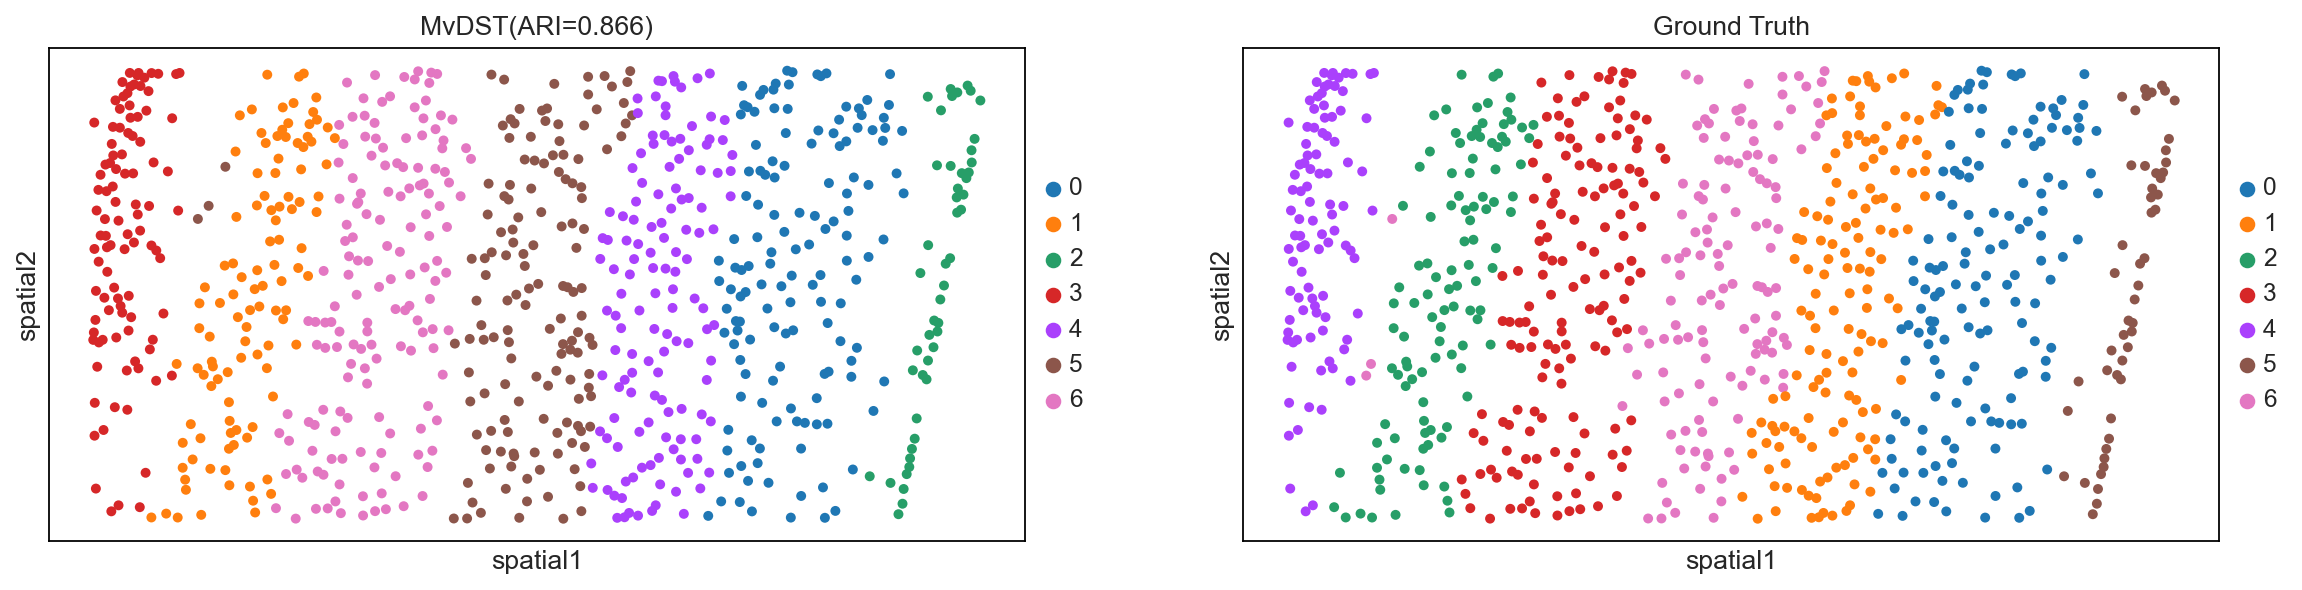

In [8]:
adata.obs['MvDST'] = best_predicted_labels
adata.obs['MvDST'] = adata.obs['MvDST'].astype('str')
adata.obs['MvDST'] = adata.obs['MvDST'].astype('category')
sc.pl.embedding(adata, basis="spatial", color=['MvDST', 'tissue_id_refine'],title=['MvDST(ARI=%.3f)'% ari,  'Ground Truth'], s=80)